# AI Lab Assignment: Data Preprocessing & Visualization
**Student Assignment - Data Preprocessing Pipeline**

Dataset: Top 1000 Movies from IMDb

## Importing Libraries
In this section, we import essential libraries that will help us explore and analyze the dataset.
- `pandas` for data manipulation.
- `numpy` for numerical operations.
- `sklearn` for preprocessing (StandardScaler) and dimensionality reduction (PCA).
- `matplotlib` and `seaborn` for visualizations.

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

Let's load the **Top 1000 Movies from IMDb** dataset. Since it's stored online, we use `pd.read_csv()` to read it directly from the URL.

In [3]:
url = "https://raw.githubusercontent.com/krishna-koly/IMDB_TOP_1000/refs/heads/main/imdb_top_1000.csv"
df = pd.read_csv(url)
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   str    
 1   Series_Title   1000 non-null   str    
 2   Released_Year  1000 non-null   str    
 3   Certificate    899 non-null    str    
 4   Runtime        1000 non-null   str    
 5   Genre          1000 non-null   str    
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   str    
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   str    
 10  Star1          1000 non-null   str    
 11  Star2          1000 non-null   str    
 12  Star3          1000 non-null   str    
 13  Star4          1000 non-null   str    
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    str    
dtypes: float64(2), int64(1), str(13)
memory usage: 519.7 KB
None
                                         Poster

# Part 1: Data Preprocessing Pipeline

## Step 1: Data Cleaning

### Checking for Missing Values
First we check which columns have missing values

In [4]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64


### Handling Missing Values

I can see that:
- **Certificate**: 101 missing values - I'll fill with "Not Rated" since it's categorical
- **Meta_score**: 157 missing values - I'll use median since it's numerical and less affected by outliers
- **Gross**: 169 missing values - I'll use median for the same reason

**Strategy 1**: For categorical data (Certificate) → fill with a meaningful category "Not Rated"

**Strategy 2**: For numerical data (Meta_score, Gross) → fill with median (more robust than mean for data with outliers)

In [5]:
df["Certificate"] = df["Certificate"].fillna("Not Rated")

df["Meta_score"] = df["Meta_score"].fillna(df["Meta_score"].median())

df['Gross'] = df['Gross'].str.replace(',', '', regex=False)
df['Gross'] = pd.to_numeric(df['Gross'], errors='coerce')
median_gross = df['Gross'].median()
df['Gross'] = df['Gross'].fillna(median_gross)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Poster_Link      0
Series_Title     0
Released_Year    0
Certificate      0
Runtime          0
Genre            0
IMDB_Rating      0
Overview         0
Meta_score       0
Director         0
Star1            0
Star2            0
Star3            0
Star4            0
No_of_Votes      0
Gross            0
dtype: int64


### Detecting and Handling Outliers

Using the IQR method from the lecture
I'll check outliers in Gross revenue since box office numbers can be extreme.

In [6]:
Q1 = df['Gross'].quantile(0.25)
Q3 = df['Gross'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['Gross'] = df['Gross'].clip(lower=lower_bound, upper=upper_bound)

### Fixing Data Inconsistencies

Runtime column has " min" text that needs to be removed

In [7]:
df['Runtime'] = df['Runtime'].str.replace(' min', '', regex=False)
df['Runtime'] = pd.to_numeric(df['Runtime'], errors='coerce')

df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')

print("Data types after cleaning:")
print(df.dtypes)

Data types after cleaning:
Poster_Link          str
Series_Title         str
Released_Year    float64
Certificate          str
Runtime            int64
Genre                str
IMDB_Rating      float64
Overview             str
Meta_score       float64
Director             str
Star1                str
Star2                str
Star3                str
Star4                str
No_of_Votes        int64
Gross            float64
dtype: object


---
## Step 2: Data Transformation

### Normalization
I'll normalize IMDB_Rating and Meta_score to 0-1 range so they're on the same scale

In [8]:
scaler = MinMaxScaler()
df[['IMDB_Rating', 'Meta_score']] = scaler.fit_transform(df[['IMDB_Rating', 'Meta_score']])

print("Normalized ratings:")
print(df[['IMDB_Rating', 'Meta_score']].describe())

Normalized ratings:
       IMDB_Rating   Meta_score
count  1000.000000  1000.000000
mean      0.205471     0.696292
std       0.162054     0.157892
min       0.000000     0.000000
25%       0.058824     0.611111
50%       0.176471     0.708333
75%       0.294118     0.795139
max       1.000000     1.000000


### Encoding Categorical Variables

Using **one-hot encoding** for Genre since there's no natural order

In [9]:
genres_split = df['Genre'].str.get_dummies(sep=', ')
df = pd.concat([df, genres_split], axis=1)

print(f"Genre columns created: {list(genres_split.columns)}")
print(f"Dataset shape: {df.shape}")

Genre columns created: ['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Sport', 'Thriller', 'War', 'Western']
Dataset shape: (1000, 37)


---
## Step 3: Data Reduction

### Removing Unnecessary Columns
Removing columns that won't help with analysis

In [10]:
cols_to_remove = ['Poster_Link', 'Overview', 'Director', 'Star1', 'Star2', 'Star3', 'Star4']
df = df.drop(columns=[col for col in cols_to_remove if col in df.columns])
print(f"Dataset shape after removing columns: {df.shape}")

Dataset shape after removing columns: (1000, 30)


### Correlation Analysis

Using **Pearson correlation** to find highly correlated features.
Features with correlation > 0.9 are redundant.

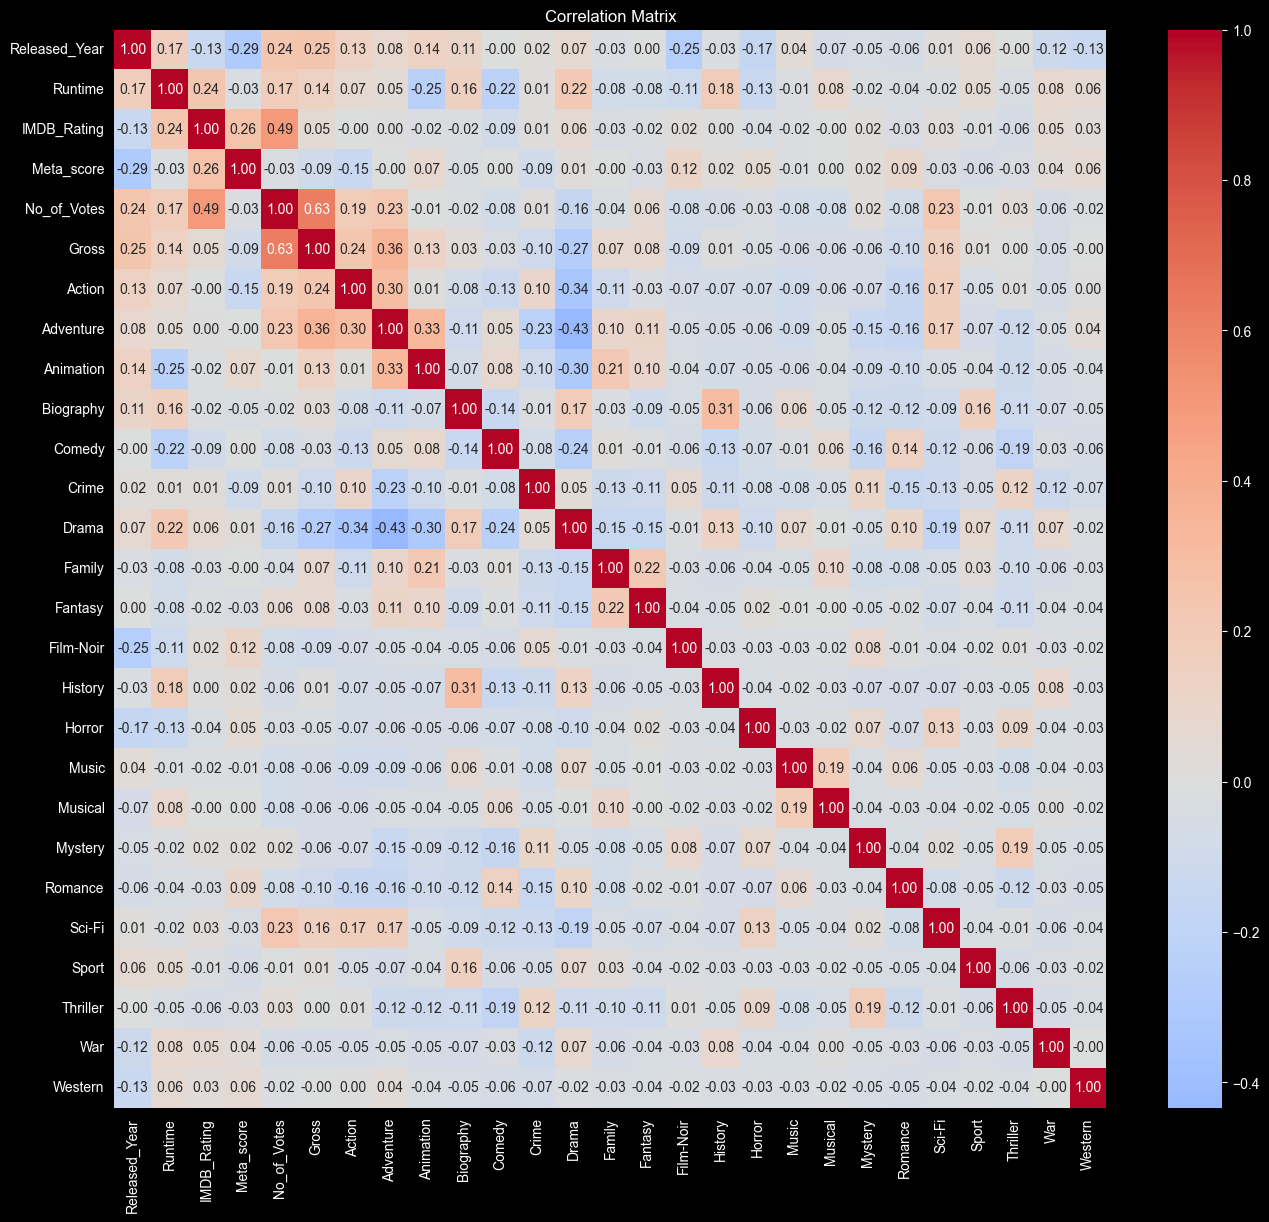

In [11]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,)

plt.title('Correlation Matrix')
plt.show()

### Removing Low-Variance Features

Features with very low variance don't add useful information

In [12]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
non_numeric_df = df.select_dtypes(exclude=[np.number])

selector = VarianceThreshold(threshold=0.01)
numeric_filtered = pd.DataFrame(
    selector.fit_transform(df[numeric_cols]),
    columns=numeric_cols[selector.get_support()],
    index=df.index)

df = pd.concat([non_numeric_df, numeric_filtered], axis=1)
df.head(10)

,Series_Title,Certificate,Genre,Released_Year,Runtime,IMDB_Rating,Meta_score,No_of_Votes,Gross,Action,...,Horror,Music,Musical,Mystery,Romance,Sci-Fi,Sport,Thriller,War,Western
0,The Shawshank Redemption,A,Drama,1994.0,142.0,1.000000,0.722222,2343110.0,2.834147e+07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,The Godfather,A,"Crime, Drama",1972.0,175.0,0.941176,1.000000,1620367.0,1.349664e+08,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,The Dark Knight,UA,"Action, Crime, Drama",2008.0,152.0,0.823529,0.777778,2303232.0,1.463303e+08,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,The Godfather: Part II,A,"Crime, Drama",1974.0,202.0,0.823529,0.861111,1129952.0,5.730000e+07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,12 Angry Men,U,"Crime, Drama",1957.0,96.0,0.823529,0.944444,689845.0,4.360000e+06,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,The Lord of the Rings: The Return of the King,U,"Action, Adventure, Drama",2003.0,201.0,0.764706,0.916667,1642758.0,1.463303e+08,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Pulp Fiction,A,"Crime, Drama",1994.0,154.0,0.764706,0.916667,1826188.0,1.079288e+08,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,Schindler's List,A,"Biography, Drama, History",1993.0,195.0,0.764706,0.916667,1213505.0,9.689882e+07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,Inception,UA,"Action, Adventure, Sci-Fi",2010.0,148.0,0.705882,0.638889,2067042.0,1.463303e+08,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9,Fight Club,A,Drama,1999.0,139.0,0.705882,0.527778,1854740.0,3.703010e+07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Dimensionality Reduction with PCA

Applying **PCA** to genre columns to reduce dimensions while keeping high variance

In [13]:
scaler = StandardScaler()
df = df.dropna().reset_index(drop=True)
scaler_data = scaler.fit_transform(df.select_dtypes(include=[np.number]))

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaler_data)

df_pca = pd.DataFrame(pca_result, columns=["PCA_1", "PCA_2"])
df = pd.concat([df, df_pca], axis=1)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
df_pca.head(10)


Explained variance ratio: [0.10242275 0.08038451]


,PCA_1,PCA_2
0,2.161603,3.612648
1,1.697732,3.673925
2,3.725160,4.522309
3,0.508637,3.334403
4,-0.717698,0.845363
5,4.116331,3.903421
6,1.827286,3.444718
7,0.553303,5.110936
8,6.437534,3.103967
9,1.663277,2.910162


---
## Step 4: Feature Engineering

Creating a **Success_Score** metric that combines:
- IMDB Rating (audience reception)
- Meta Score (critic reception) 
- Gross revenue (commercial success)

In [14]:
# Normalize Gross to 0-1 range
gross_normalized = (df['Gross'] - df['Gross'].min()) / (df['Gross'].max() - df['Gross'].min())

df['Success_Score'] = (df['IMDB_Rating'] + df['Meta_score'] + gross_normalized) / 3

print("Top 10 movies by Success Score:")
print(df[['Series_Title', 'IMDB_Rating', 'Meta_score', 'Gross', 'Success_Score']].sort_values('Success_Score', ascending=False).head(10))

print("\nSuccess Score statistics:")
print(df['Success_Score'].describe())

Top 10 movies by Success Score:
                                         Series_Title  IMDB_Rating  \
1                                       The Godfather     0.941176   
5       The Lord of the Rings: The Return of the King     0.764706   
2                                     The Dark Knight     0.823529   
10  The Lord of the Rings: The Fellowship of the Ring     0.705882   
13              The Lord of the Rings: The Two Towers     0.647059   
24                                Saving Private Ryan     0.588235   
11                                       Forrest Gump     0.705882   
29                                          Star Wars     0.588235   
6                                        Pulp Fiction     0.764706   
66                                             WALLE     0.470588   

    Meta_score         Gross  Success_Score  
1     1.000000  1.349664e+08       0.954505  
5     0.916667  1.463303e+08       0.893791  
2     0.777778  1.463303e+08       0.867102  
10    0.88888

---
# Part 2: Extracting & Visualizing Insights

Now I'll create 10 visualizations to extract insights from the data

### Insight 1: Distribution of IMDB Ratings
Let's see how movie ratings are distributed

Insight: Most movies cluster around 0.75-0.85 rating, which makes sense since this is the TOP 1000 list!

Interesting: Very few movies have ratings below 0.5 or above 0.9. This suggests that the top movies are generally well-received, but there's a "ceiling" effect where it's hard to achieve near-perfect ratings.

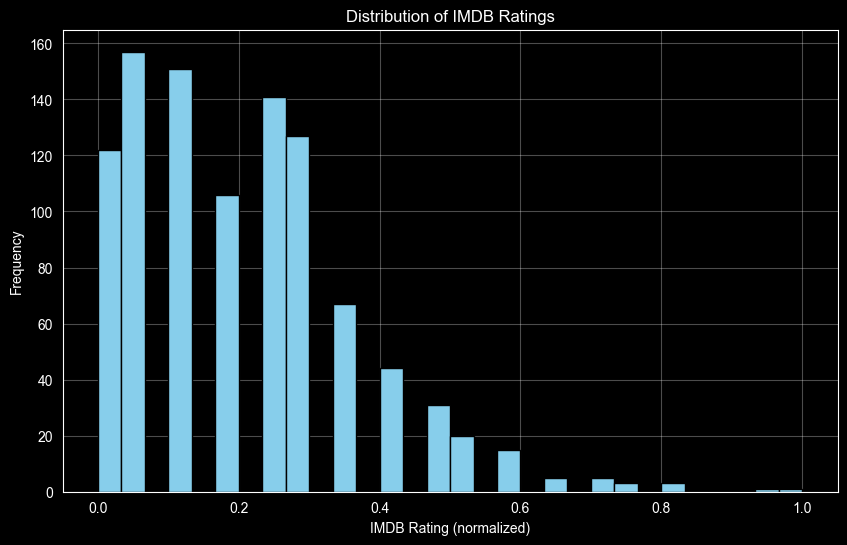

In [15]:
plt.figure(figsize=(10, 6))
plt.hist(df['IMDB_Rating'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('IMDB Rating (normalized)')
plt.ylabel('Frequency')
plt.title('Distribution of IMDB Ratings')
plt.grid(True, alpha=0.3)
plt.show()

### Insight 2: Release Year Trend

Insight: There's a huge spike in recent years (2000s onwards)

Interesting: This could be due to recency bias - newer movies are fresher in people's minds and get more votes/ratings.

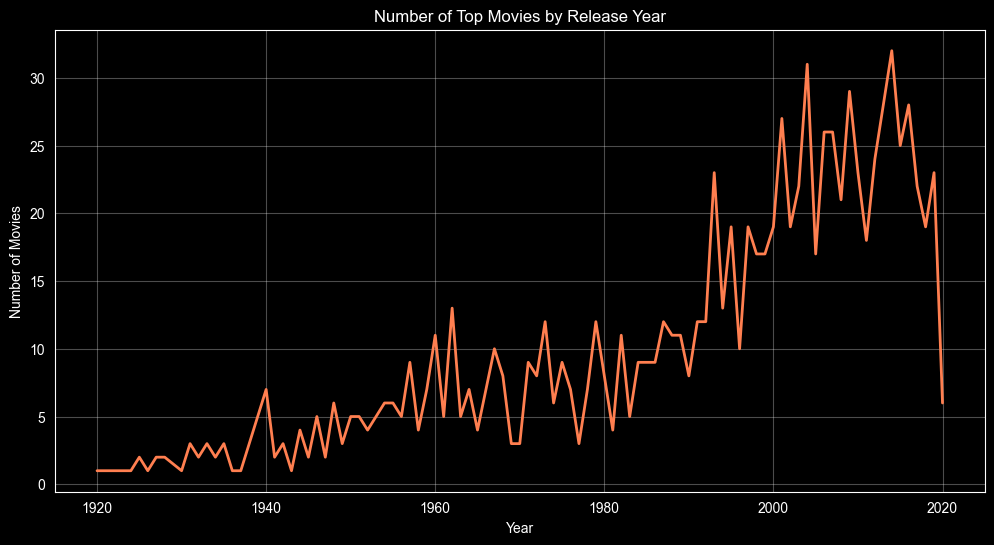

In [16]:
plt.figure(figsize=(12, 6))
year_counts = df['Released_Year'].value_counts().sort_index()
plt.plot(year_counts.index, year_counts.values, linewidth=2, color='coral')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.title('Number of Top Movies by Release Year')
plt.grid(True, alpha=0.3)
plt.show()

### Insight 3: Runtime Distribution

Insight: Most great movies are around 2 hours long (120 min).

Interesting: Very few movies are under 90 minutes or over 180 minutes. Maybe there's a "sweet spot" for movie length that audiences and critics prefer?

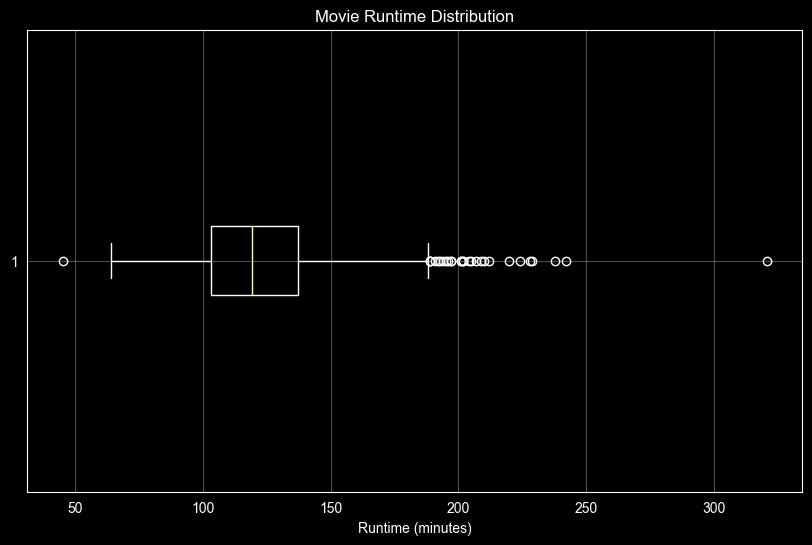

Average runtime: 123 minutes
Median runtime: 119 minutes


In [17]:
plt.figure(figsize=(10, 6))
plt.boxplot(df['Runtime'].dropna(), vert=False)
plt.xlabel('Runtime (minutes)')
plt.title('Movie Runtime Distribution')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average runtime: {df['Runtime'].mean():.0f} minutes")
print(f"Median runtime: {df['Runtime'].median():.0f} minutes")

### Insight 4: Top Genres

Insight: Drama dominates! Almost every great movie has some drama element.

Interesting: Romance is not that common in the top 1000. Maybe love stories don't score as high?

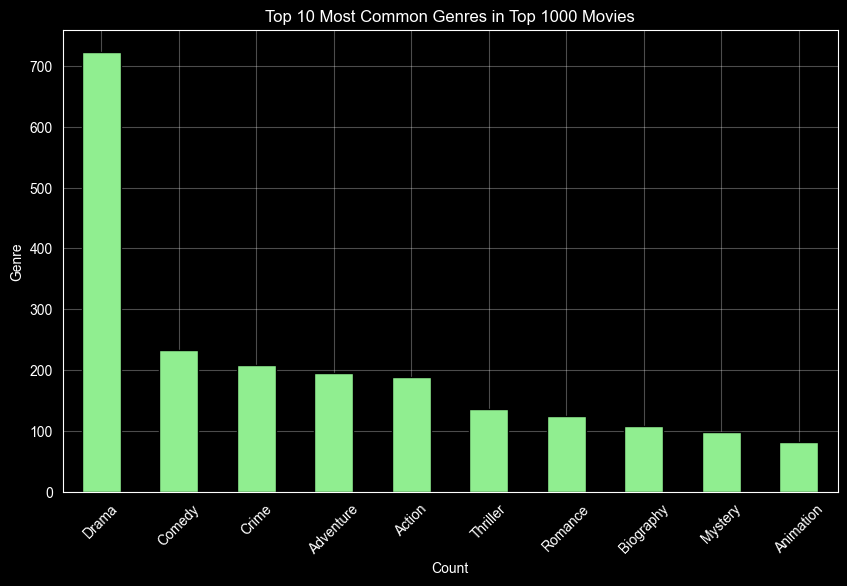

In [18]:
genre_counts = df[genres_split.columns].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
genre_counts.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.title('Top 10 Most Common Genres in Top 1000 Movies')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

### Insight 5: IMDB Rating vs Meta Score Correlation

Insight: There's a positive correlation but not perfect!

Interesting: The correlation coefficient is around 0.25, which means that while critics and audiences sometimes agree, there are many cases where they don't. Some movies are loved by audiences but not critics (and vice versa). This highlights the subjective nature of movie appreciation!

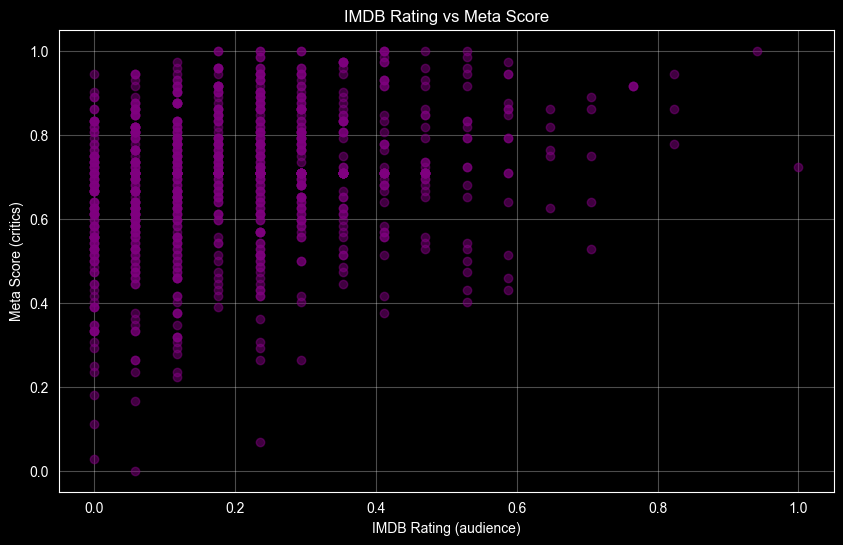

Correlation: 0.259


In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(df['IMDB_Rating'], df['Meta_score'], alpha=0.5, color='purple')
plt.xlabel('IMDB Rating (audience)')
plt.ylabel('Meta Score (critics)')
plt.title('IMDB Rating vs Meta Score')
plt.grid(True, alpha=0.3)
plt.show()

correlation = df['IMDB_Rating'].corr(df['Meta_score'])
print(f"Correlation: {correlation:.3f}")

### Insight 6: Gross Revenue vs IMDB Rating

Insight: Weak correlation! High-rated movies don't necessarily make more money.

Interesting: The correlation coefficient is around 0.05, which means that while some high-rated movies do well at the box office, many don't. This suggests that commercial success depends on factors beyond just quality - like marketing, star power, and franchise appeal.

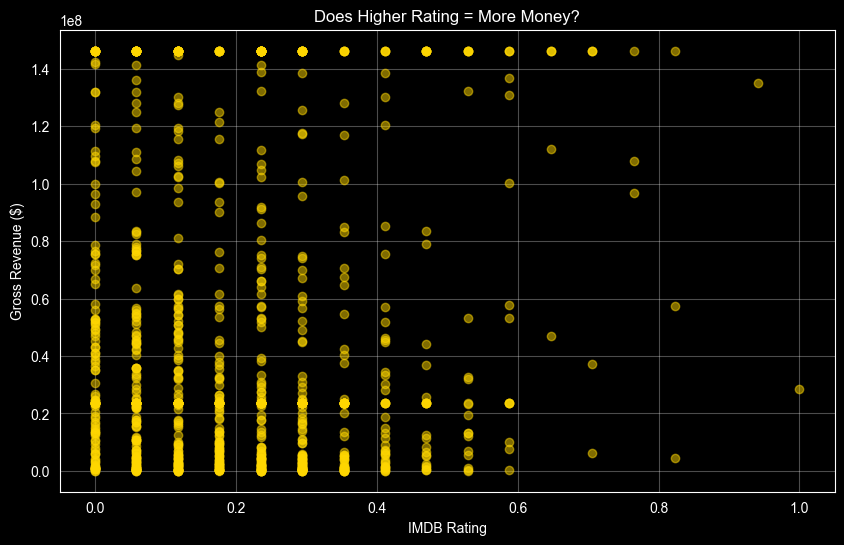

Correlation: 0.052


In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(df['IMDB_Rating'], df['Gross'], alpha=0.5, color='gold')
plt.xlabel('IMDB Rating')
plt.ylabel('Gross Revenue ($)')
plt.title('Does Higher Rating = More Money?')
plt.grid(True, alpha=0.3)
plt.show()

correlation = df['IMDB_Rating'].corr(df['Gross'])
print(f"Correlation: {correlation:.3f}")

### Insight 7: Certificate Distribution

Insight: Most top movies are rated A (Adult) or UA (Universal Adult).

Interesting: Very few movies are rated U (Universal) or R (Restricted). Maybe the top 1000 list favors more mature themes that resonate with critics and audiences?

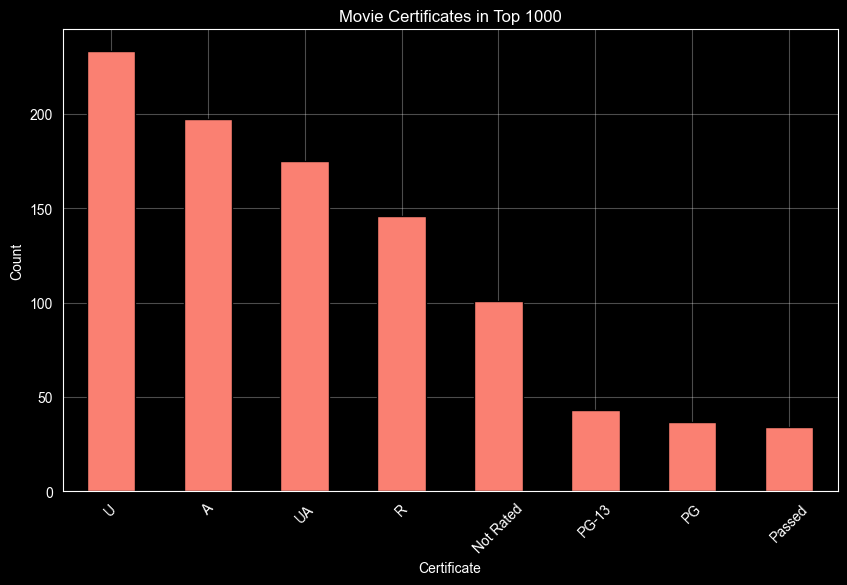

In [21]:
plt.figure(figsize=(10, 6))
cert_counts = df['Certificate'].value_counts().head(8)
cert_counts.plot(kind='bar', color='salmon', edgecolor='black')
plt.xlabel('Certificate')
plt.ylabel('Count')
plt.title('Movie Certificates in Top 1000')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

### Insight 8: Number of Votes Distribution

Insight: Extremely right-skewed! A few movies have MASSIVE vote counts.

Interesting: The top 10 movies have over 1 million votes each - these are the true blockbusters that everyone has seen. The majority of movies have much lower vote counts, indicating that while they may be critically acclaimed, they haven't reached the same level of mainstream popularity.

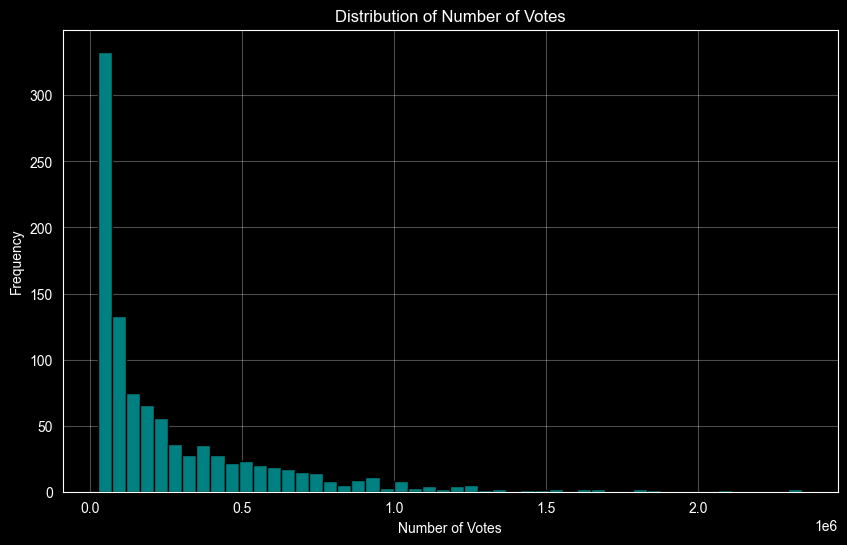

Average votes: 273697
Median votes: 138356


In [22]:
plt.figure(figsize=(10, 6))
plt.hist(df['No_of_Votes'], bins=50, color='teal', edgecolor='black')
plt.xlabel('Number of Votes')
plt.ylabel('Frequency')
plt.title('Distribution of Number of Votes')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average votes: {df['No_of_Votes'].mean():.0f}")
print(f"Median votes: {df['No_of_Votes'].median():.0f}")

### Insight 9: Success Score Distribution

Insight: The Success Score (combining ratings and revenue) shows a normal-ish distribution.

Interesting: Most movies cluster around 0.3-0.4 success score. Only a few elite movies achieve very high success across all metrics!

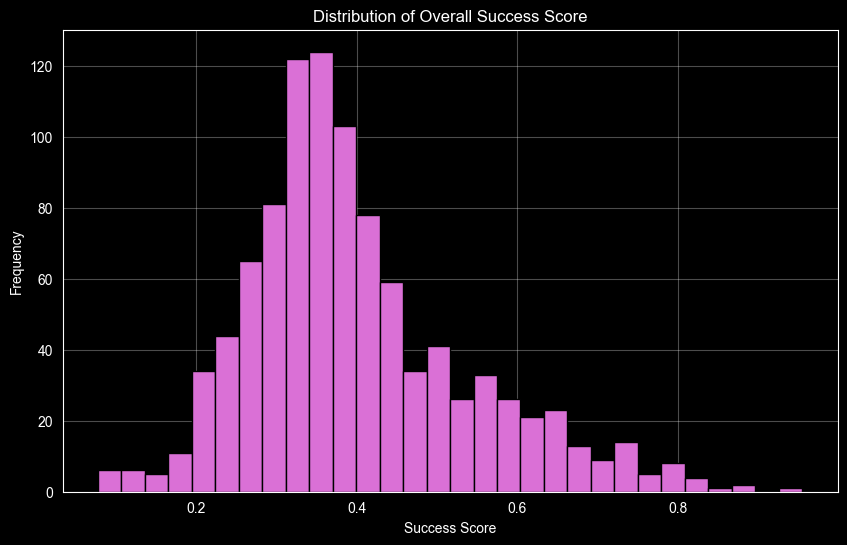

In [23]:
plt.figure(figsize=(10, 6))
plt.hist(df['Success_Score'], bins=30, color='orchid', edgecolor='black')
plt.xlabel('Success Score')
plt.ylabel('Frequency')
plt.title('Distribution of Overall Success Score')
plt.grid(True, alpha=0.3)
plt.show()

### Insight 10: Correlation Heatmap

Insight:
**IMDB Rating** and **Meta Score** are moderately correlated (critics vs audience).

**Gross** revenue doesn't correlate much with ratings - money ≠ quality!

**Number of Votes** correlates with **Gross** - popular movies make more money.

**Success Score** balances all metrics nicely.


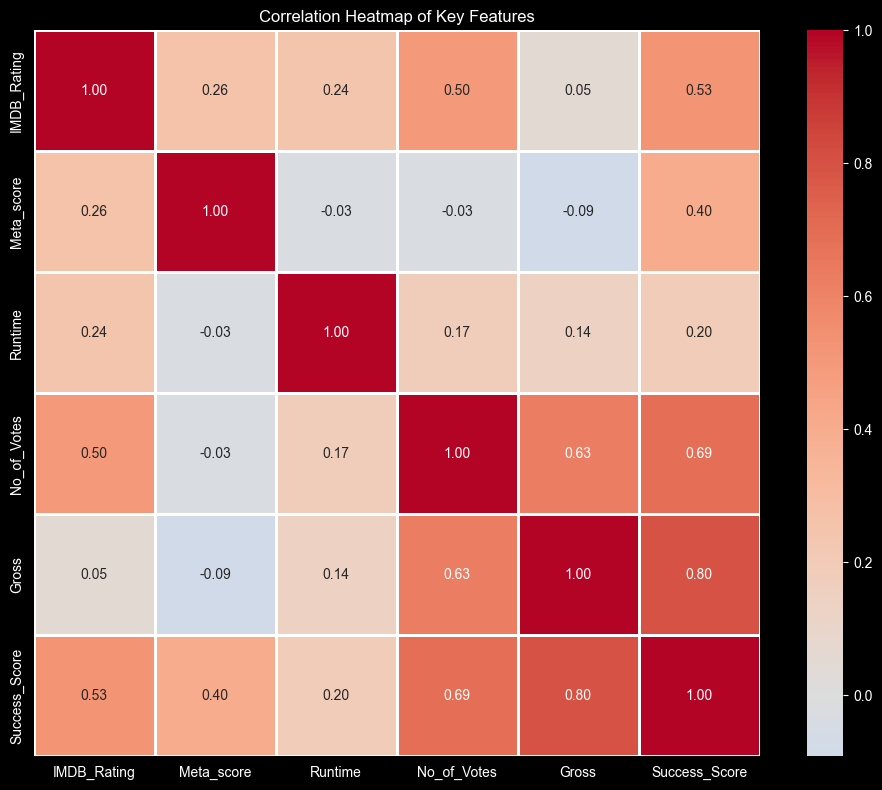

In [24]:
key_features = ['IMDB_Rating', 'Meta_score', 'Runtime', 'No_of_Votes', 'Gross', 'Success_Score']
corr_data = df[key_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1)
plt.title('Correlation Heatmap of Key Features')
plt.tight_layout()
plt.show()

---
# Part 3: Movie Recommendation System (Without AI)

## Building a Simple Content-Based Recommender

My approach: Calculate similarity based on:
1. Genre similarity
2. Rating similarity (IMDB + Meta score)
3. Runtime similarity
4. Release year proximity

I'll use a weighted combination of these factors to find the most similar movies.

In [25]:
def recommend_movies(movie_title, df, top_n=5):
    movie_idx = df[df['Series_Title'].str.contains(movie_title, case=False, na=False)].index

    if len(movie_idx) == 0:
        print(f"Movie '{movie_title}' not found!")
        return None

    movie_idx = movie_idx[0]

    genre_cols = [col for col in genres_split.columns if col in df.columns]
    feature_cols = ['IMDB_Rating', 'Meta_score', 'Runtime', 'Released_Year'] + genre_cols

    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(df[feature_cols].fillna(0))

    similarity_scores = cosine_similarity(features_scaled)[movie_idx]

    similar_indices = similarity_scores.argsort()[::-1]
    similar_indices = similar_indices[similar_indices != movie_idx][:top_n]

    recommendations = df.iloc[similar_indices][['Series_Title','Released_Year', 'Genre','IMDB_Rating', 'Meta_score']].copy()
    recommendations['Similarity_Score'] = similarity_scores[similar_indices]
    
    return recommendations

### Testing the Recommendation System

In [26]:
# Test 1: Dark Knight
print("If you liked 'The Dark Knight', you might also like:")
recommendations = recommend_movies("Dark Knight", df, top_n=5)
if recommendations is not None:
    print(recommendations)

If you liked 'The Dark Knight', you might also like:
      Series_Title  Released_Year                 Genre  IMDB_Rating  \
55    Vikram Vedha         2017.0  Action, Crime, Drama     0.470588   
6     Pulp Fiction         1994.0          Crime, Drama     0.764706   
42            Lon         1994.0  Action, Crime, Drama     0.529412   
22  Cidade de Deus         2002.0          Crime, Drama     0.588235   
1    The Godfather         1972.0          Crime, Drama     0.941176   

    Meta_score  Similarity_Score  
55    0.708333          0.913728  
6     0.916667          0.841785  
42    0.500000          0.813826  
22    0.708333          0.813633  
1     1.000000          0.808727  


In [27]:
# Test 2: Titanic
print("If you liked 'Titanic', you might also like:")
recommendations = recommend_movies("Titanic", df, top_n=5)
if recommendations is not None:
    print(recommendations)

If you liked 'Titanic', you might also like:
                      Series_Title  Released_Year           Genre  \
258    Dilwale Dulhania Le Jayenge         1995.0  Drama, Romance   
734                 La vie d'Adle         2013.0  Drama, Romance   
350                          Dev.D         2009.0  Drama, Romance   
661         The Remains of the Day         1993.0  Drama, Romance   
965  The Bridges of Madison County         1995.0  Drama, Romance   

     IMDB_Rating  Meta_score  Similarity_Score  
258     0.294118    0.708333          0.957495  
734     0.058824    0.847222          0.926681  
350     0.235294    0.708333          0.866867  
661     0.117647    0.777778          0.824111  
965     0.000000    0.569444          0.823679  


In [28]:
# Test 3: Inception
print("If you liked 'Inception', you might also like:")
recommendations = recommend_movies("Inception", df, top_n=5)
if recommendations is not None:
    print(recommendations)

If you liked 'Inception', you might also like:
                   Series_Title  Released_Year                      Genre  \
60       Avengers: Infinity War         2018.0  Action, Adventure, Sci-Fi   
106                      Aliens         1986.0  Action, Adventure, Sci-Fi   
14                   The Matrix         1999.0             Action, Sci-Fi   
262               Jurassic Park         1993.0  Action, Adventure, Sci-Fi   
44   Terminator 2: Judgment Day         1991.0             Action, Sci-Fi   

     IMDB_Rating  Meta_score  Similarity_Score  
60      0.470588    0.555556          0.967029  
106     0.411765    0.777778          0.928757  
14      0.647059    0.625000          0.903561  
262     0.294118    0.555556          0.890475  
44      0.529412    0.652778          0.882436  
